In [44]:
import sys
import numpy as np
import pandas as pd
!{sys.executable} -m pip install shap

DEPRECATION: pyodbc 4.0.0-unsupported has a non-standard version number. pip 24.1 will enforce this behaviour change. A possible replacement is to upgrade to a newer version of pyodbc or contact the author to suggest that they release a version with a conforming version number. Discussion can be found at https://github.com/pypa/pip/issues/12063


In [45]:
df = pd.read_pickle('data/df.pkl')

# # Aspect: convert to radians and compute sin/cos
# df['aspect_min_cos'] = np.cos(np.radians(df['aspect_min']))
# df['aspect_min_sin'] = np.sin(np.radians(df['aspect_min']))

# df['aspect_max_cos'] = np.cos(np.radians(df['aspect_max']))
# df['aspect_max_sin'] = np.sin(np.radians(df['aspect_max']))

# df['aspect_mean_cos'] = np.cos(np.radians(df['aspect_mean']))
# df['aspect_mean_sin'] = np.sin(np.radians(df['aspect_mean']))

# # Drop raw aspect values
# df = df.drop(columns=['aspect_min', 'aspect_max', 'aspect_mean'])

# # --- Slope quantities ---
# # Translate slope (steepness) and aspect (direction) into slope components
# # Convention: slope_x = downslope in east-west direction
# #             slope_y = downslope in north-south direction

# df['slope_x'] = df['slope_mean'] * df['aspect_mean_cos']
# df['slope_y'] = df['slope_mean'] * df['aspect_mean_sin']

# # Optional: could also add slope magnitude transforms
# df['slope_squared'] = df['slope_mean'] ** 2
# df['slope_log'] = np.log1p(df['slope_mean'])  # log(1 + slope)


# df['water_availability'] = df['ppt_sum'] / df['gdd_sum']
# df['diurnal_temp_range'] = df['tmax_mean'] / df['tmin_avg']
# df['stress_index'] = df['vpdmax_mean'] / df['ppt_sum']
# df['local_relief'] = df['elev_mean'] - df['elev_min']
# df['vpdmin_mean2'] = df['vpdmin_mean']**2
# df['vpdmin_max2'] = df['vpdmin_max']**2
# df['vpdmin_min2'] = df['vpdmin_min']**2
# df['vpdmax_mean2'] = df['vpdmax_mean']**2
# df['vpdmax_mean2'] = df['vpdmax_mean']**2
# df['vpdmax_mean2'] = df['vpdmax_mean']**2

In [46]:
df.columns

Index(['year', 'plot_id', 'ndvi_peak', 'ndvi_peak_doy', 'ndvi_min',
       'ndvi_integral', 'ndvi_sos', 'ndvi_eos', 'ndvi_los',
       'ndvi_greenup_slope',
       ...
       'aspect_max_cos', 'aspect_max_sin', 'aspect_mean_cos',
       'aspect_mean_sin', 'slope_x', 'slope_y', 'slope_squared', 'slope_log',
       'local_relief', 'total_relief_log'],
      dtype='object', length=124)

In [47]:
# # Example interactions
# df['vpdmax_tmax_min'] = df['vpdmax_mean'] * df['tmax_min']
# # Slope × aspect components using precomputed sine/cosine
# df['slope_x'] = df['slope_mean'] * df['aspect_mean_sin']   # east-west component
# df['slope_y'] = df['slope_mean'] * df['aspect_mean_cos']   # north-south component

In [48]:
ndvi_cols = [col for col in df.columns if 'ndvi' in col] + ['year', 'plot_id', 'geometry', 'key_0', 'area_m2']

# ndvi_cols = ndvi_cols.append('year')
# ndvi_cols = ndvi_cols.append('plot_id')


In [49]:
ndvi_acc_cols = [
    'ndvi_sos',
    'ndvi_greenup_slope',
]

In [50]:
ndvi_cols

['ndvi_peak',
 'ndvi_peak_doy',
 'ndvi_min',
 'ndvi_integral',
 'ndvi_sos',
 'ndvi_eos',
 'ndvi_los',
 'ndvi_greenup_slope',
 'ndvi_senescence_slope',
 'ndvi_early_sum',
 'ndvi_mid_sum',
 'ndvi_late_sum',
 'ndvi_early_mean',
 'ndvi_mid_mean',
 'ndvi_late_mean',
 'ndvi_early_min',
 'ndvi_early_max',
 'ndvi_mid_min',
 'ndvi_mid_max',
 'ndvi_late_min',
 'ndvi_late_max',
 'year',
 'plot_id',
 'geometry',
 'key_0',
 'area_m2']

In [51]:
x = df.drop(columns = ndvi_cols, axis = 1)
y = (df['ndvi_integral'])

In [52]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

In [53]:
from sklearn.model_selection import train_test_split

# First split off the test set (say 20%)
X_temp, X_test, y_temp, y_test = train_test_split(
    x_scaled, y, test_size=0.2, random_state=42
)

# Then split the remaining into train + validation (say 20% of remaining)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42
)


In [54]:
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, mean_squared_error

model = Ridge(alpha=1.0)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("R2:", r2_score(y_test, y_pred))
print("RMSE:", mean_squared_error(y_test, y_pred, squared=False))


R2: 0.5736161179713186
RMSE: 8.383748725246416


In [55]:
from sklearn.linear_model import RidgeCV
from sklearn.pipeline import Pipeline

ridge_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', RidgeCV(alphas=[0.1, 1.0, 10.0], cv=10))
])

ridge_pipeline.fit(X_train, y_train)
print("Best alpha:", ridge_pipeline.named_steps['ridge'].alpha_)
print("Train R^2:", ridge_pipeline.score(X_train, y_train))
print("Test R^2:", ridge_pipeline.score(X_test, y_test))


Best alpha: 10.0
Train R^2: 0.6047709526619569
Test R^2: 0.5751379438513637


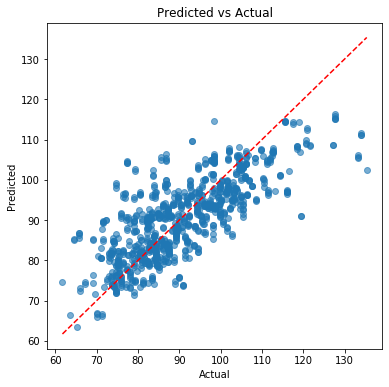

In [56]:
import matplotlib.pyplot as plt

y_pred = ridge_pipeline.predict(X_test)

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Predicted vs Actual")
plt.show()


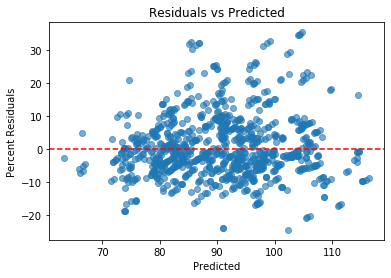

In [57]:
residuals = y_test - y_pred
plt.figure(figsize=(6,4))
plt.scatter(y_pred, (y_pred - y_test) / y_test * 100, alpha=0.6)
plt.axhline(0, color='r', linestyle='--')
plt.xlabel("Predicted")
plt.ylabel("Percent Residuals")
plt.title("Residuals vs Predicted")
plt.show()


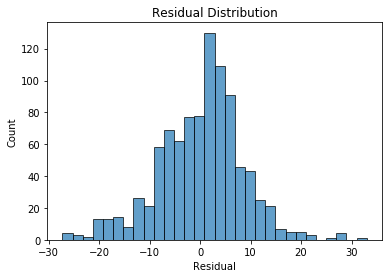

In [58]:
plt.hist(residuals, bins=30, edgecolor='k', alpha=0.7)
plt.xlabel("Residual")
plt.ylabel("Count")
plt.title("Residual Distribution")
plt.show()


Top 20 Ridge Features by Importance:
total_relief       -8.408315
slope_x            -7.502000
aspect_max_cos     -5.880127
aspect_mean_sin     5.627876
aspect_mean_cos     4.910756
total_relief_log    4.731773
slope_log           4.199952
slope_min          -3.877279
slope_squared      -3.395661
area_ha             3.380955
vpdmax_early_min    1.669268
vpdmax_mean        -1.633059
vpdmin_early_max    1.520272
slope_mean          1.448531
local_relief        1.346700
slope_y            -1.308870
vpdmax_mid_min     -1.241207
aspect_min_sin     -1.223192
gdd_sum             1.188561
ppt_early          -1.138429
dtype: float64


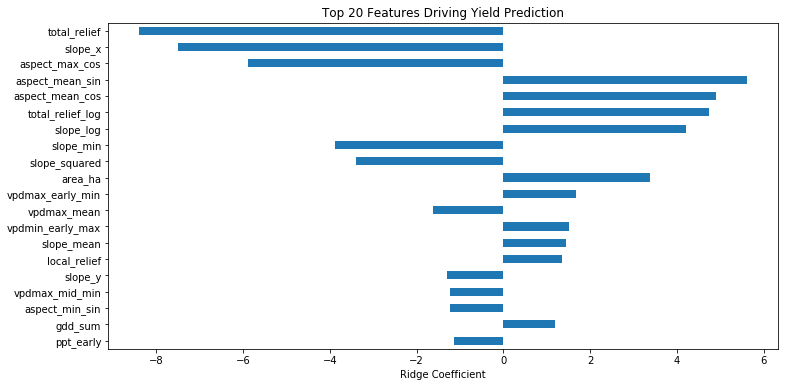

In [59]:
# Extract coefficients from Ridge model
ridge_coef = ridge_pipeline.named_steps['ridge'].coef_

# Map to feature names
feature_importance = pd.Series(ridge_coef, index=x.columns)

# Rank by absolute value
feature_importance_sorted = feature_importance.reindex(feature_importance.abs().sort_values(ascending=False).index)

# Show top 20 features
print("Top 20 Ridge Features by Importance:")
print(feature_importance_sorted.head(20))

# Optional: plot
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
feature_importance_sorted.head(20).plot(kind='barh')
plt.gca().invert_yaxis()
plt.xlabel("Ridge Coefficient")
plt.title("Top 20 Features Driving Yield Prediction")
plt.show()


In [17]:
# from sklearn.linear_model import LassoCV

# lasso_pipeline = Pipeline([
#     ('scaler', StandardScaler()),
#     ('lasso', LassoCV(alphas=None, cv=5, max_iter=5000))
# ])

# lasso_pipeline.fit(X_train, y_train)
# coef = pd.Series(lasso_pipeline.named_steps['lasso'].coef_, index=x.columns)
# selected_features = coef[coef != 0].index.tolist()

# print("Selected features:", selected_features)


In [18]:
# df['ppt_sum'] = np.log10(df['ppt_sum'])
# df = df.drop('ppt_min', axis = 1)

In [19]:
# # List of skewed features to log-transform
# log_features = ['ppt_sum', 'area_ha', 'vpdmax_mean']

# # Apply log1p (log(1 + x)) to handle zeros
# for f in log_features:
#     df[f + '_log'] = np.log1p(df[f])


In [20]:

# # Clip extreme outliers at 99th percentile
# clip_features = ['vpdmax_mean', 'vpdmin_mean', 'tmax_max']

# for f in clip_features:
#     upper = df[f].quantile(0.99)
#     df[f + '_clip'] = df[f].clip(upper=upper)


In [21]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
import numpy as np

# Prepare features/target
# X = df.drop(columns=ndvi_cols)
# y = df['ndvi_integral']
# X['vpdmax_mean'].clip(upper=X['vpdmax_mean'].quantile(0.99))
# Simple train/test split (e.g., 80/20 by plots)
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Random Forest
rf = RandomForestRegressor(n_estimators=2000, max_depth=20, min_samples_leaf = 2 ,random_state=42)
rf.fit(X_train, y_train)

# Predictions
y_pred = rf.predict(X_test)

# Metrics
r2 = r2_score(y_test, y_pred)
print("Test R²:", r2)

Top 10 Features:
 tmin_mid_max       0.268532
aspect_mean_cos    0.117296
slope_y            0.076323
slope_min          0.054994
area_ha            0.038114
aspect_max_sin     0.025874
slope_max          0.025561
tmean_mid_max      0.022705
aspect_mean_sin    0.022064
elev_dev_max       0.019571
elev_max           0.018978
local_relief       0.016081
slope_squared      0.014546
slope_mean         0.013852
slope_log          0.013815
elev_mean          0.013132
elev_dev_mean      0.013006
elev_min           0.012547
tmax_mid_mean      0.012183
elev_dev_min       0.012151
dtype: float64


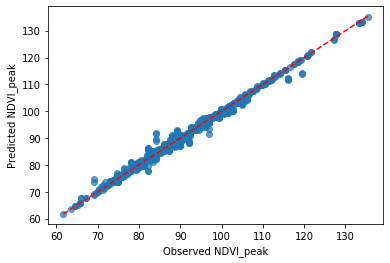

In [23]:
# Feature importance
feat_imp = pd.Series(rf.feature_importances_, index=x.columns).sort_values(ascending=False)
print("Top 10 Features:\n", feat_imp.head(20))

# Optional: predicted vs observed plot
plt.figure()
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.xlabel("Observed NDVI_peak")
plt.ylabel("Predicted NDVI_peak")
# plt.title(f"Random Forest Predictions (R²={r2:.2f})")
plt.show()

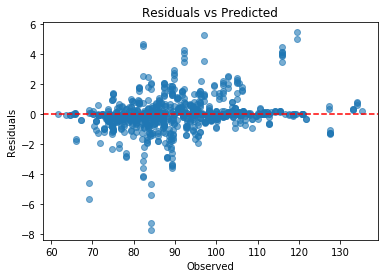

In [24]:
residuals = y_test - y_pred
plt.figure()
plt.scatter(y_test, residuals, alpha=0.6)
plt.axhline(0, color='r', linestyle='--')
plt.xlabel("Observed")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted")
plt.show()


In [25]:
df

,year,plot_id,ndvi_peak,ndvi_peak_doy,ndvi_min,ndvi_integral,ndvi_sos,ndvi_eos,ndvi_los,ndvi_greenup_slope,...,aspect_max_cos,aspect_max_sin,aspect_mean_cos,aspect_mean_sin,slope_x,slope_y,slope_squared,slope_log,local_relief,total_relief_log
0,2016,28,0.339791,231,0.0,88.921832,67,366,299,0.000852,...,-0.898852,-0.438251,-0.914146,0.405386,3.983210,-8.982139,96.544778,2.381925,20.606571,3.900337
1,2016,28,0.339791,231,0.0,88.921832,67,366,299,0.000852,...,-0.898852,-0.438251,-0.914146,0.405386,3.983210,-8.982139,96.544778,2.381925,20.606571,3.900337
2,2016,28,0.339791,231,0.0,88.921832,67,366,299,0.000852,...,-0.898852,-0.438251,-0.914146,0.405386,3.983210,-8.982139,96.544778,2.381925,20.606571,3.900337
3,2016,28,0.339791,231,0.0,88.921832,67,366,299,0.000852,...,-0.898852,-0.438251,-0.914146,0.405386,3.983210,-8.982139,96.544778,2.381925,20.606571,3.900337
4,2016,28,0.339791,231,0.0,88.921832,67,366,299,0.000852,...,-0.898852,-0.438251,-0.914146,0.405386,3.983210,-8.982139,96.544778,2.381925,20.606571,3.900337
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4687,2018,42,0.366904,197,0.0,105.798990,19,366,347,0.000923,...,1.000000,-0.000070,0.412797,-0.910823,-4.942879,2.240177,29.450443,1.860481,15.834244,3.437559
4688,2018,42,0.366904,197,0.0,105.798990,19,366,347,0.000923,...,1.000000,-0.000070,0.412797,-0.910823,-4.942879,2.240177,29.450443,1.860481,15.834244,3.437559
4689,2018,42,0.366904,197,0.0,105.798990,19,366,347,0.000923,...,1.000000,-0.000070,0.412797,-0.910823,-4.942879,2.240177,29.450443,1.860481,15.834244,3.437559
4690,2018,42,0.366904,197,0.0,105.798990,19,366,347,0.000923,...,1.000000,-0.000070,0.412797,-0.910823,-4.942879,2.240177,29.450443,1.860481,15.834244,3.437559


In [29]:
from patsy import dmatrix
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
import pandas as pd
import numpy as np

# Example: RF output (top 10 features)
rf_importances = {
    "slope_min": 0.101617,
    "vpdmax_mean": 0.075734,
    "gdd_sum": 0.061846,
    "tmin_avg": 0.058997,
    "aspect_max_sin": 0.056345,
    "tmin_min": 0.056135,
    "slope_y": 0.055343,
    "slope_mean": 0.046890,
    "total_relief": 0.043732,
    "vpdmin_min": 0.041481,
    "tmean_min": 0.041140,
    "aspect_mean_cos": 0.035164,
    "area_ha": 0.024896,
    "aspect_min_sin": 0.022565,
    "elev_min": 0.020954,
    "aspect_min_cos": 0.020908,
    "elev_dev_min": 0.019653,
    "slope_x": 0.019556,
    "elev_max": 0.018152,
    "slope_max": 0.017920,
}

# Decide spline vs linear based on importance threshold
importance_threshold = 0.02  # features above this get splines
spline_cols = [k for k, v in rf_importances.items() if v >= importance_threshold]
linear_cols = [c for c in x.columns if c not in spline_cols]

# Build spline-expanded dataframe
spline_dfs = []
for col in spline_cols:
    # You can adjust df per feature based on importance if you want
    spline_df = dmatrix(f"bs(X['{col}'], df=4, degree=3, include_intercept=False)", 
                        {"X": x}, return_type="dataframe")
    spline_df.columns = [f"{col}_spline{i}" for i in range(spline_df.shape[1])]
    spline_dfs.append(spline_df)

# Combine splines + linear features
X_spline = pd.concat(spline_dfs + [x[linear_cols].reset_index(drop=True)], axis=1)

# Train/test split
# X_train, X_test, y_train, y_test = train_test_split(X_spline, y, test_size=0.2, random_state=42)

# Fit Ridge
ridge = Ridge(alpha=0.1)
ridge.fit(X_train, y_train)
y_pred = ridge.predict(X_test)

# Metrics
r2 = r2_score(y_test, y_pred)
print("Test R²:", r2)

# Feature importance
coef_df = pd.Series(ridge.coef_, index=X_spline.columns)
coef_df = coef_df.reindex(coef_df.abs().sort_values(ascending=False).index)
print("Top 20 features by absolute coefficient:\n", coef_df.head(20))


Test R²: 0.5729471919432922


ValueError: Length of passed values is 98, index implies 162.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Top spline features to visualize
top_spline_features = ['aspect_mean_sin', 'aspect_mean_cos', 'aspect_min_sin', 'aspect_min_cos', 'aspect_max_sin','aspect_max_cos']

plt.figure(figsize=(15, 4 * len(top_spline_features)))

for i, feature in enumerate(top_spline_features):
    # Identify spline columns for this feature
    spline_cols = [c for c in X_spline.columns if c.startswith(feature + "_spline")]
    
    # Extract values from training set (X[feature]) for plotting
    x_train_vals = X[feature].values
    sort_idx = np.argsort(x_train_vals)
    
    # Contribution of feature to prediction
    coefs = ridge.coef_[[X_spline.columns.get_loc(c) for c in spline_cols]]
    y_spline = X_spline[spline_cols].values @ coefs
    
    # Plot sorted values vs contribution
    plt.subplot(len(top_spline_features), 1, i + 1)
    plt.plot(x_train_vals[sort_idx], y_spline[sort_idx], color='orange', lw=2, label=f"{feature} spline effect")
    plt.xlabel(feature)
    plt.ylabel("Contribution to NDVI_peak")
    plt.title(f"Spline Effect of {feature} on Ridge Prediction")
    plt.grid(True)
    plt.legend()

plt.tight_layout()
plt.show()


In [ ]:
# import matplotlib.pyplot as plt
# import numpy as np

# # Pick top spline features to visualize
# top_spline_features = ['elev_dev_min', 'aspect_mean', 'area_ha', 'slope_min']

# plt.figure(figsize=(15, 4 * len(top_spline_features)))

# for i, feature in enumerate(top_spline_features):
#     # Identify all spline columns for this feature
#     spline_cols = [c for c in X_spline.columns if c.startswith(feature + "_spline")]
    
#     # Extract feature values from original X
#     x_vals = X[feature].values
#     sort_idx = np.argsort(x_vals)
    
#     # Coefficients for this feature's splines
#     coefs = ridge.coef_[[X_spline.columns.get_loc(c) for c in spline_cols]]
    
#     # Contribution of the feature
#     y_spline = X_spline[spline_cols].values @ coefs
    
#     # Plot
#     plt.subplot(len(top_spline_features), 1, i + 1)
#     plt.plot(x_vals[sort_idx], y_spline[sort_idx], color='orange', lw=2)
#     plt.xlabel(feature)
#     plt.ylabel("Contribution to NDVI_peak")
#     plt.title(f"Spline effect of {feature}")
#     plt.grid(True)

# plt.tight_layout()
# plt.savefig('spline_curves.png')
# plt.show()


In [ ]:
df.columns

In [ ]:
ndvi_cols

In [ ]:
# from sklearn.model_selection import GridSearchCV
# from xgboost import XGBRegressor


In [ ]:
# param_grid = {
#     'learning_rate': [0.01, 0.03, 0.05],
#     'max_depth': [3, 5, 7],
#     'min_child_weight': [1, 3, 5],
#     # 'subsample': [0.7, 0.85, 1.0],
#     # 'colsample_bytree': [0.6, 0.8, 1.0],
#     'n_estimators': [100, 500, 1000]
# }


In [ ]:
# xgb_model = XGBRegressor(
#     objective='reg:squarederror',
#     random_state=42,
#     eval_metric='rmse'
# )


In [ ]:
# kf = KFold(n_splits=5, shuffle=True, random_state=42)

# grid_search = GridSearchCV(
#     estimator=xgb_model,
#     param_grid=param_grid,
#     scoring='r2',
#     cv=kf,
#     verbose=2,
#     n_jobs=-1
# )

# grid_search.fit(X, y)


In [ ]:
# print("Best R²:", grid_search.best_score_)
# print("Best parameters:", grid_search.best_params_)


In [ ]:
# best_params = grid_search.best_params_

# final_model = XGBRegressor(**best_params, random_state=42)
# final_model.fit(X_train, y_train)
# y_pred = final_model.predict(X_test)
# r2 = r2_score(y_test, y_pred)
# print("Test R²:", r2)


In [60]:
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Scale features + small MLP
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', MLPRegressor(
        hidden_layer_sizes=(64, 32, 16),
        activation='relu',
        solver='adam',
        max_iter=5000,
        early_stopping=True,
        random_state=42
    ))
])

pipeline.fit(X_train, y_train)

y_val_pred = pipeline.predict(X_val)

In [63]:
residuals = y_val_pred - y_test

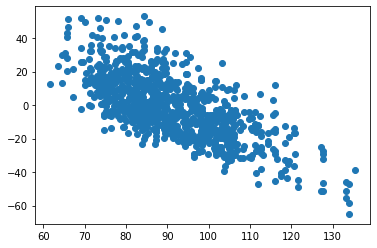

In [65]:

plt.scatter(y_test, residuals)

Series([], Name: ndvi_integral, dtype: float64)

In [38]:
import xgboost as xgb
from xgboost import XGBRegressor
from sklearn.metrics import r2_score


# Initialize model
xgb_model = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.25,
    max_depth=3,
    subsample=0.85,
    colsample_bytree=0.7,
    min_child_weight=3,
    random_state=42,
    eval_metric='rmse'
)

# Fit with eval_set to track training/validation loss
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    early_stopping_rounds=10,
    verbose=False
)

/home/simonhans/anaconda3/lib/python3.7/site-packages/xgboost/sklearn.py:797: UserWarning: `early_stopping_rounds` in `fit` method is deprecated for better compatibility with scikit-learn, use `early_stopping_rounds` in constructor or`set_params` instead.
  UserWarning,


XGBRegressor(base_score=0.5, booster='gbtree', callbacks=None,
             colsample_bylevel=1, colsample_bynode=1, colsample_bytree=0.7,
             early_stopping_rounds=None, enable_categorical=False,
             eval_metric='rmse', gamma=0, gpu_id=-1, grow_policy='depthwise',
             importance_type=None, interaction_constraints='',
             learning_rate=0.25, max_bin=256, max_cat_to_onehot=4,
             max_delta_step=0, max_depth=3, max_leaves=0, min_child_weight=3,
             missing=nan, monotone_constraints='()', n_estimators=1000,
             n_jobs=0, num_parallel_tree=1, predictor='auto', random_state=42,
             reg_alpha=0, reg_lambda=1, ...)

In [40]:
y_pred

array([           inf,            inf, 6.72869155e+32,            inf,
                  inf,            inf,            inf, 5.42846690e+35,
                  inf, 8.80785238e+37, 2.32619463e+36,            inf,
       3.40035895e+38,            inf, 4.73176447e+37,            inf,
       1.03296743e+36, 1.01812280e+32, 8.74881104e+36, 4.83984889e+34,
       6.53455662e+35, 8.04743201e+36,            inf, 8.45933173e+32,
       3.53485485e+37, 3.13393457e+32,            inf,            inf,
       2.58668770e+37,            inf,            inf,            inf,
       5.92869094e+36, 8.42177823e+37,            inf, 1.91873179e+37,
                  inf, 2.07322461e+34,            inf,            inf,
       4.48070565e+26, 1.92349984e+34, 3.31128510e+34, 8.12086283e+37,
                  inf,            inf,            inf,            inf,
                  inf,            inf, 2.57500006e+36, 9.04552571e+37,
       1.06782806e+35, 6.83339276e+37, 7.46025663e+37, 6.50508077e+34,
      

In [39]:

# ------------------------
# Predict and evaluate
# ------------------------
y_test = np.exp(y_test)
y = np.exp(y)
y_pred =np.exp(xgb_model.predict(X_test))
r2 = r2_score(y_test, y_pred)
print("Test R²:", r2)

# ------------------------
# Feature importance
# ------------------------
importances = xgb_model.feature_importances_
feat_imp = dict(zip(X.columns, importances))
print("Top features:", sorted(feat_imp.items(), key=lambda x: x[1], reverse=True)[:10])

/home/simonhans/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:6: RuntimeWarning: overflow encountered in exp
  


ValueError: Input contains NaN, infinity or a value too large for dtype('float64').

In [ ]:
plt.hist(y)
plt.show()

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', linewidth=2)
plt.xlabel("Observed NDVI Integral")
plt.ylabel("Predicted NDVI Integral")
plt.title("XGBoost Predictions vs Observed")
plt.savefig('img/pred_vs_obs.png')
plt.show()


In [ ]:
residuals = y_pred - y_test
plt.figure(figsize=(8, 6))
plt.scatter(y_test, residuals / y_test * 100, alpha=0.6)
plt.axhline(0, color='r', linestyle='--')
plt.xlabel("Observed NDVI Integral")
plt.ylabel("Residuals")
plt.title("Percent Residuals vs Predicted")
plt.savefig('img/residuals.png')
plt.show()


In [ ]:
import numpy as np
import pandas as pd

# y_true, y_pred are your arrays/series for the test set
resid = y_pred - y_test
pct_resid = 100 * resid / y_test

df_diag = pd.DataFrame({'y_true': y_test, 'y_pred': y_pred, 'resid': resid, 'pct_resid': pct_resid})

# bin by observed value (5 quantile bins) to see systematic bias
bins = np.quantile(df_diag['y_true'], np.linspace(0, 1, 6))
df_diag['bin'] = pd.cut(df_diag['y_true'], bins=bins, include_lowest=True)
bias_by_bin = df_diag.groupby('bin')['resid'].mean()
print(bias_by_bin)


In [ ]:
import pandas as pd
import seaborn as sns

feat_imp = pd.DataFrame({
    "feature": X.columns,
    "importance": xgb_model.feature_importances_
}).sort_values("importance", ascending=False)

plt.figure(figsize=(17,10))
sns.barplot(x="importance", y="feature", data=feat_imp.head(10))
plt.title("Feature Importances (XGBoost)", fontsize = 18)
plt.xlabel("Importance", fontsize = 16)
plt.ylabel("Feature", fontsize = 16)
plt.xticks(size = 14)
plt.yticks(size = 14)
plt.savefig('img/feature_imp.png')
plt.show()


In [ ]:
# import xgboost as xgb

# model = xgb.XGBRegressor(
#     n_estimators=1,
#     max_depth=5,
#     learning_rate=0.05,
#     subsample=0.8,
#     colsample_bytree=0.8,
#     random_state=42
# )

# model.fit(
#     X_train, y_train,
#     eval_set=[(X_train, y_train), (X_test, y_test)],
#     eval_metric='rmse',
#     verbose=False
# )


In [ ]:
results = xgb_model.evals_result()  # only works for XGBRegressor / xgb.train()
epochs = len(results['validation_0']['rmse'])

import matplotlib.pyplot as plt
plt.figure(figsize=(8,6))
plt.plot(range(epochs), results['validation_0']['rmse'], label='Train RMSE')
plt.plot(range(epochs), results['validation_1']['rmse'], label='Test RMSE')
plt.xlabel('Boosting round')
plt.ylabel('RMSE')
plt.title('XGBoost Learning Curve')
plt.legend()
plt.show()


In [ ]:
import matplotlib.pyplot as plt

results = xgb_model.evals_result()
plt.plot(results['validation_0']['rmse'], label='Train RMSE')
plt.plot(results['validation_1']['rmse'], label='Test RMSE')
plt.axvline(xgb_model.best_iteration, color='red', linestyle='--', label='Early stop')
plt.xlabel('Boosting round')
plt.ylabel('RMSE')
plt.title('XGBoost Learning Curve')
plt.legend()
plt.show()


In [ ]:
# import matplotlib.pyplot as plt
# from sklearn.inspection import PartialDependenceDisplay

# top_features = ['frost_days', 'tmin_avg', 'vpdmax_mean', 'aspect_mean_cos']

# # Loop over features and plot individually
# for feat in X.columns:
#     fig, ax = plt.subplots(figsize=(6, 4))
#     PartialDependenceDisplay.from_estimator(
#         xgb_model,
#         X_test,
#         [feat],
#         kind='both',  # PDP + ICE
#         subsample=100,  # sample for ICE clarity
#         ax=ax
#     )
#     ax.set_title(f'PDP + ICE: {feat}')
#     plt.show()
